In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import shap

In [2]:
df = pd.read_json("../data/supervise_myth_clusters.json", lines=True)
df.head()

,id,text,type,source,imdb_title,imdb_year,imdb_genres,inferred_media_type,combined_text,has_semantic_match,has_lexical_match,has_sentence_myth_trope_hit,max_trope_similarity,myth_hit_count,myth_theme,cluster,has_myth_hit,has_myth_trope_hit,agglo_cluster
0,media_acesciencefictionspecials,Ace Science Fiction Specials is a Science fict...,modern_media,Science Fiction Book Series,Science Fiction special,1986.0,"[comedy, crime, fantasy, horror, sci-fi, thril...",both,Ace Science Fiction Special Science Fiction sp...,True,False,True,0.000000,0,"Rebirth, Prophecy & Fate",2,False,False,0
1,media_listofacesfdoubletitles,List of Ace SF double titles is a Science fict...,modern_media,Science Fiction Book Series,None,NaN,None,skip,,True,False,True,0.000000,0,"Shapeshifters, Rebirth & Primal Archetypes",1,False,False,7
2,media_listofacesfletter-seriessingletitles,List of Ace SF letter-series single titles is ...,modern_media,Science Fiction Book Series,None,NaN,None,skip,,True,False,True,0.000000,0,"Shapeshifters, Rebirth & Primal Archetypes",1,False,False,7
3,media_listofacesfnumeric-seriessingletitles,List of Ace SF numeric-series single titles is...,modern_media,Science Fiction Book Series,None,NaN,None,skip,,True,False,True,0.000000,0,"Shapeshifters, Rebirth & Primal Archetypes",1,False,False,7
4,media_acorna,Acorna is a Science fiction book series from w...,modern_media,Science Fiction Book Series,None,NaN,None,book,Acorna Science fiction roman.,True,False,True,0.023044,0,"Rebirth, Prophecy & Fate",2,False,False,5


In [4]:
categorical_features = ["inferred_media_type"]
numerical_features = ["myth_hit_count", "max_trope_similarity", "imdb_year"]
boolean_features = ["has_lexical_match", "has_semantic_match", "has_sentence_myth_trope_hit"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),  # or "median"
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features),
    ("bool", "passthrough", boolean_features)
])


In [6]:
y= df["agglo_cluster"]
X = df[numerical_features + categorical_features + boolean_features]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

In [9]:
results = {}

for name, clf in classifiers.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    pipeline.fit(X_train, y_train)
    print(f"{name} Train Accuracy: {pipeline.score(X_train, y_train):.3f}")
    print(f"{name} Test Accuracy: {pipeline.score(X_test, y_test):.3f}\n")
    scores = cross_val_score(pipeline, X, y, cv=5, scoring="f1_macro")
    results[name] = (scores.mean(), scores.std())
    print(f"{name}: F1 = {scores.mean():.3f} ± {scores.std():.3f}")

Logistic Regression Train Accuracy: 0.515
Logistic Regression Test Accuracy: 0.510

Logistic Regression: F1 = 0.201 ± 0.010
Random Forest Train Accuracy: 0.890
Random Forest Test Accuracy: 0.604

Random Forest: F1 = 0.437 ± 0.095
KNN Train Accuracy: 0.638
KNN Test Accuracy: 0.503

KNN: F1 = 0.308 ± 0.035


In [ ]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X, y)

feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()

importances = rf_pipeline.named_steps["clf"].feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)
print(X.columns)

Index(['myth_hit_count', 'max_trope_similarity', 'imdb_year',
       'inferred_media_type', 'has_lexical_match', 'has_semantic_match',
       'has_sentence_myth_trope_hit'],
      dtype='object')


C:\Users\Eric\AppData\Local\Temp\ipykernel_28696\914376347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(10), x="importance", y="feature", palette="viridis")


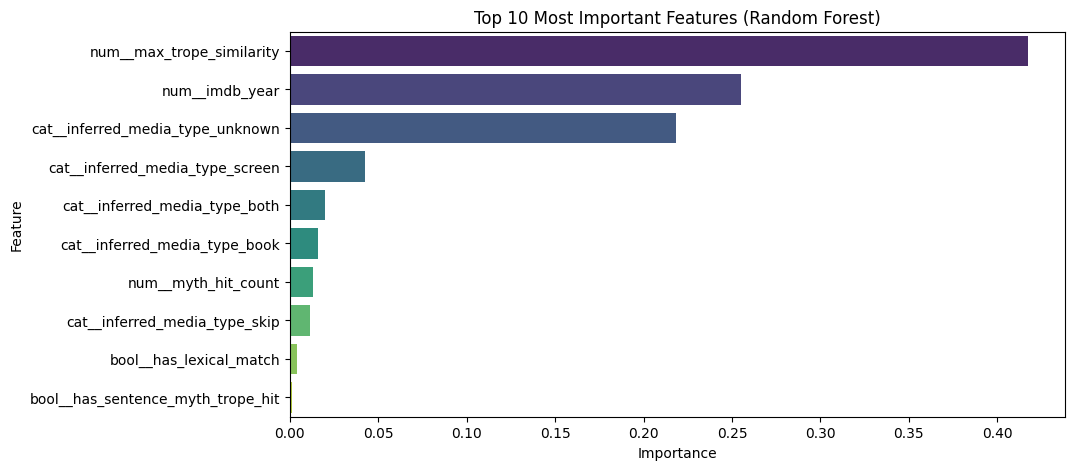

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp.head(10), x="importance", y="feature", palette="viridis")
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
reduced_features = [
    "max_trope_similarity",
    "inferred_media_type",
    "imdb_year"
]

X_reduced = df[reduced_features]
y = df["agglo_cluster"]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reduced_preprocessor = ColumnTransformer([
    ("num", numeric_pipe, ["max_trope_similarity", "imdb_year"]),
    ("cat", categorical_pipe, ["inferred_media_type"])
])

reduced_pipeline = Pipeline([
    ("preprocessor", reduced_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

scores = cross_val_score(reduced_pipeline, X_reduced, y, cv=5, scoring="f1_macro")
print(f"Reduced model F1 (macro): {scores.mean():.3f} ± {scores.std():.3f}")

Reduced model F1 (macro): 0.441 ± 0.091


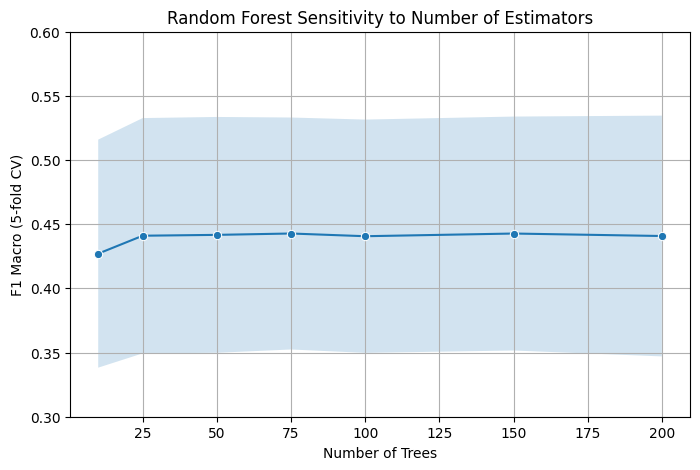

In [ ]:
#model is making almost all decisions based on max_trope_similarity, media type, and year

#hyperparameter tuning
n_estimators_range = [10, 25, 50, 75, 100, 150, 200]
results = []

for n in n_estimators_range:
    pipeline = Pipeline([
    ("preprocessor", reduced_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=n, random_state=42))
])
    scores = cross_val_score(pipeline, X_reduced, y, cv=5, scoring="f1_macro")
    results.append({
        "n_estimators": n,
        "mean_f1": scores.mean(),
        "std_f1": scores.std()
    })

sensitivity_df = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
sns.lineplot(data=sensitivity_df, x="n_estimators", y="mean_f1", marker="o")
plt.fill_between(
    sensitivity_df["n_estimators"],
    sensitivity_df["mean_f1"] - sensitivity_df["std_f1"],
    sensitivity_df["mean_f1"] + sensitivity_df["std_f1"],
    alpha=0.2
)
plt.title("Random Forest Sensitivity to Number of Estimators")
plt.xlabel("Number of Trees")
plt.ylabel("F1 Macro (5-fold CV)")
plt.ylim(0.3, 0.6)
plt.grid(True)
plt.show()

In [ ]:
#failure analysis
# Reuse the best model (Random Forest + reduced features)
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)


reduced_pipeline.fit(X_train, y_train)


y_pred = reduced_pipeline.predict(X_test)

df_test = X_test.copy()
df_test["actual"] = y_test.values
df_test["predicted"] = y_pred
df_test["correct"] = df_test["actual"] == df_test["predicted"]


failures = df_test[df_test["correct"] == False]
failures.head()

,max_trope_similarity,inferred_media_type,imdb_year,actual,predicted,correct
1213,0.000000,screen,2019.0,0,5,False
345,0.000000,both,2021.0,6,4,False
2139,0.097427,screen,2015.0,5,4,False
1485,0.059489,both,1989.0,6,0,False
1689,0.092572,screen,2005.0,0,5,False


In [18]:
failures = failures.merge(df[["id", "combined_text", "type", "inferred_media_type", "myth_theme"]], 
                          left_index=True, right_index=True, how="left")

failures.head()

,max_trope_similarity,inferred_media_type_x,imdb_year,actual,predicted,correct,id,combined_text,type,inferred_media_type_y,myth_theme
1213,0.000000,screen,2019.0,0,5,False,media_descendants3,Descendants 3,modern_media,screen,"Rebirth, Prophecy & Fate"
345,0.000000,both,2021.0,6,4,False,media_jenniferroberson,Jennifer Roberson Jennifer Robertson,modern_media,both,Divine Conflict & Deific Representation
2139,0.097427,screen,2015.0,5,4,False,media_ogres,"Ogres They go from town to town, a big top on ...",modern_media,screen,"Rebirth, Prophecy & Fate"
1485,0.059489,both,1989.0,6,0,False,media_nickknight(film),Nick Knight Nick Knight is among the world's m...,modern_media,both,Divine Conflict & Deific Representation
1689,0.092572,screen,2005.0,0,5,False,media_sugo,Sugo How can twin brothers be so different fro...,modern_media,screen,"Rebirth, Prophecy & Fate"


In [20]:
print("X_reduced columns:", X_reduced.columns.tolist())
print("Failures columns:", failures.columns.tolist())

if "inferred_media_type_x" in failures.columns:
    failures = failures.drop(columns=["inferred_media_type_y"])
    failures = failures.rename(columns={"inferred_media_type_x": "inferred_media_type"})

X_reduced columns: ['max_trope_similarity', 'inferred_media_type', 'imdb_year']
Failures columns: ['max_trope_similarity', 'inferred_media_type_x', 'imdb_year', 'actual', 'predicted', 'correct', 'id', 'combined_text', 'type', 'inferred_media_type_y', 'myth_theme']


In [21]:
explainer = shap.TreeExplainer(reduced_pipeline.named_steps["classifier"])

chosen_instance = failures.iloc[[0]]
processed_instance = reduced_pipeline.named_steps["preprocessor"].transform(chosen_instance)

shap_values = explainer.shap_values(processed_instance)

feature_names = reduced_pipeline.named_steps["preprocessor"].get_feature_names_out()
print(reduced_pipeline.named_steps["classifier"].classes_)
print("explainer.expected_value:", explainer.expected_value)
print("len(shap_values):", len(shap_values))
print("shap_values shape:", shap_values.shape)

shap.initjs()
shap.force_plot(
    explainer.expected_value[1], 
    shap_values[0, :, 1], 
    processed_instance[0],
    feature_names=feature_names
)

[0 1 2 3 4 5 6 7 8]
explainer.expected_value: [0.10866484 0.07388462 0.13831319 0.05661538 0.07107692 0.14951099
 0.04363736 0.34151099 0.01678571]
len(shap_values): 1
shap_values shape: (1, 7, 9)


1213    media_descendants3
Name: id, dtype: object
explainer.expected_value: [0.10866484 0.07388462 0.13831319 0.05661538 0.07107692 0.14951099
 0.04363736 0.34151099 0.01678571]


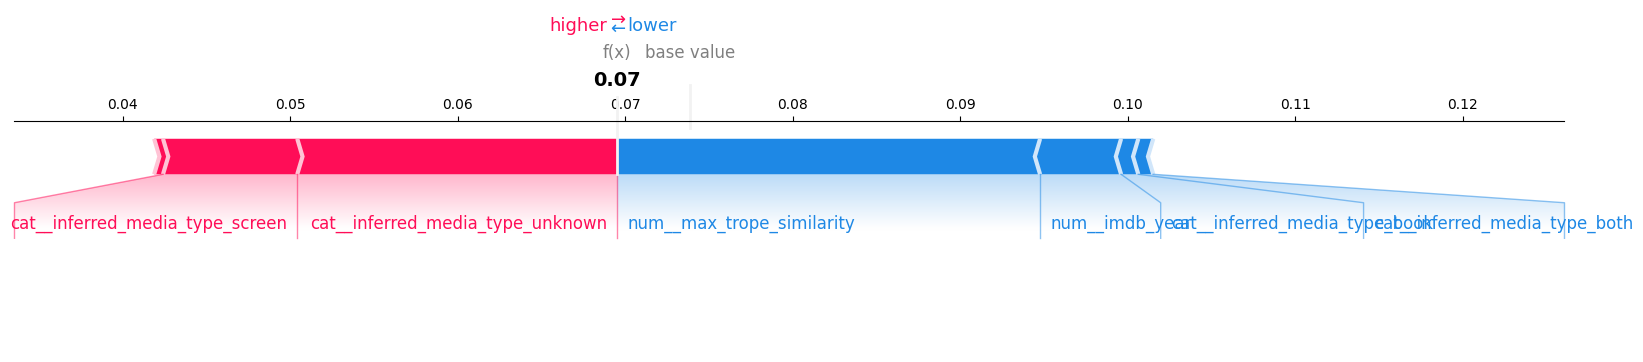

345    media_jenniferroberson
Name: id, dtype: object
explainer.expected_value: [0.10866484 0.07388462 0.13831319 0.05661538 0.07107692 0.14951099
 0.04363736 0.34151099 0.01678571]


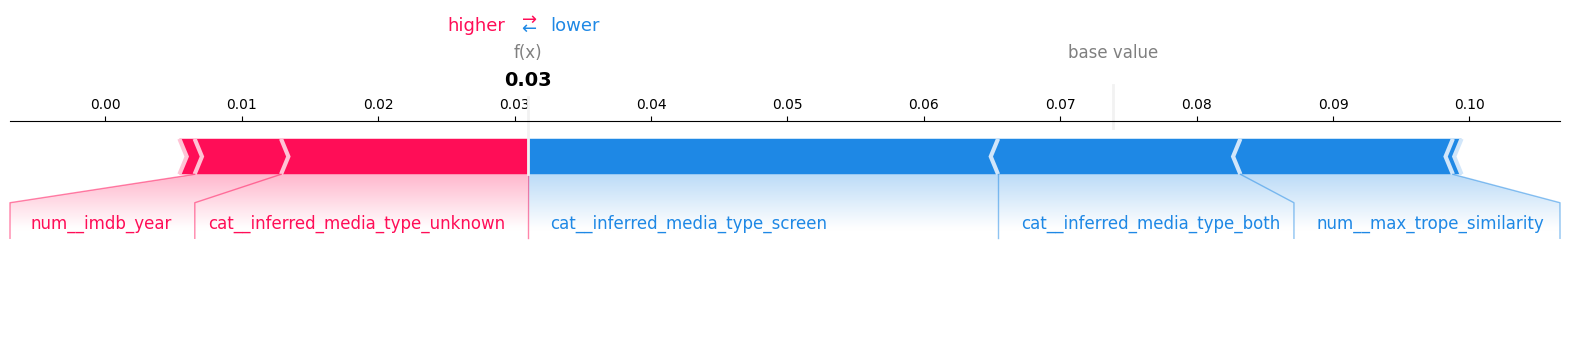

2139    media_ogres
Name: id, dtype: object
explainer.expected_value: [0.10866484 0.07388462 0.13831319 0.05661538 0.07107692 0.14951099
 0.04363736 0.34151099 0.01678571]


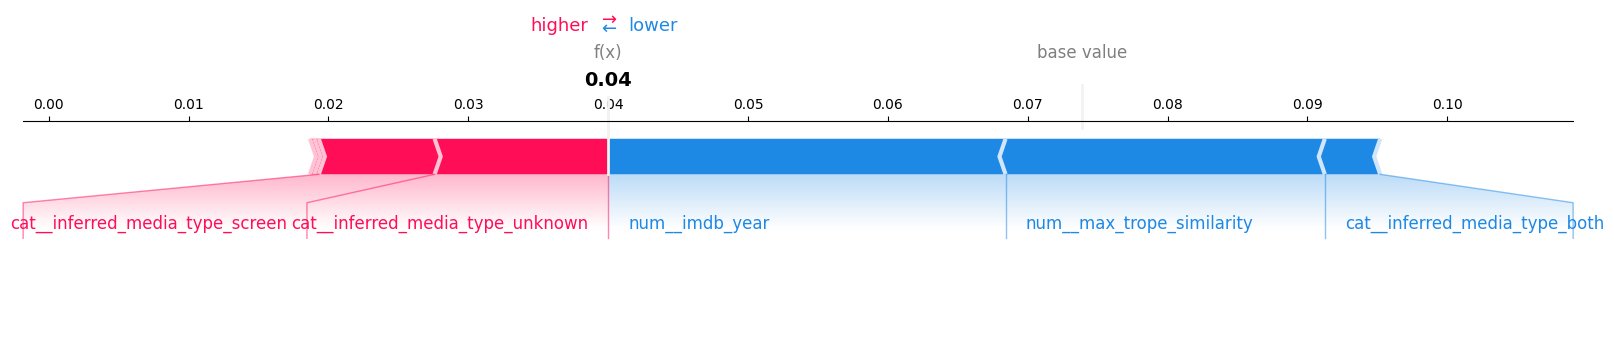

1485    media_nickknight(film)
Name: id, dtype: object
explainer.expected_value: [0.10866484 0.07388462 0.13831319 0.05661538 0.07107692 0.14951099
 0.04363736 0.34151099 0.01678571]


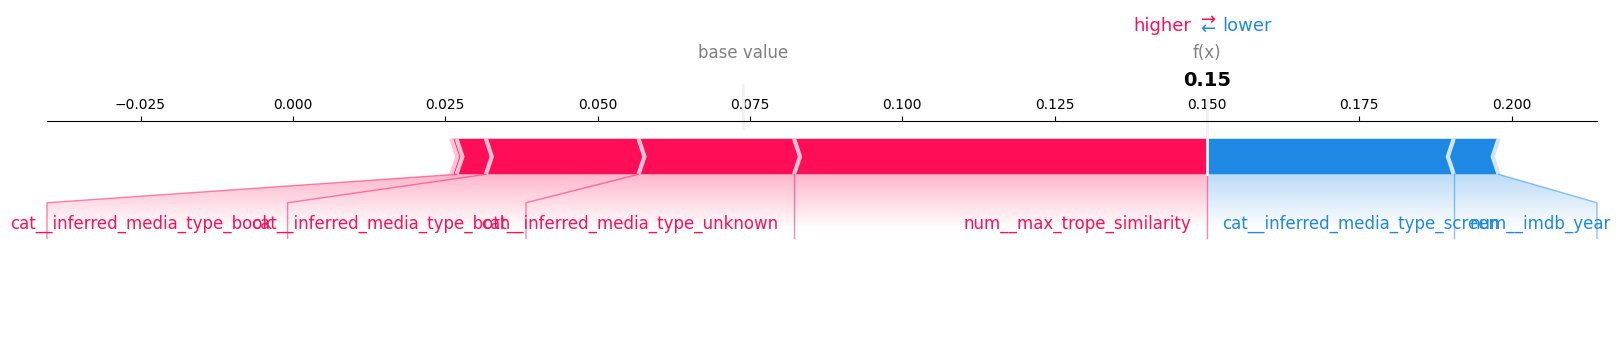

1689    media_sugo
Name: id, dtype: object
explainer.expected_value: [0.10866484 0.07388462 0.13831319 0.05661538 0.07107692 0.14951099
 0.04363736 0.34151099 0.01678571]


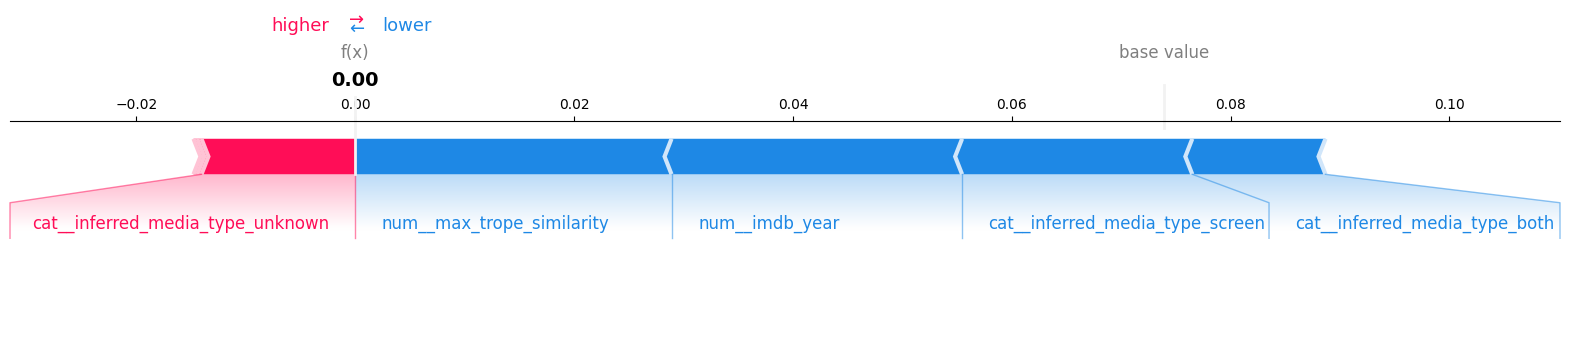

In [22]:
num_failures = 5

for i in range(0, num_failures):

    chosen_instance = failures.iloc[[i]]
    processed_instance = reduced_pipeline.named_steps["preprocessor"].transform(chosen_instance)

    shap_values = explainer.shap_values(processed_instance)

    feature_names = reduced_pipeline.named_steps["preprocessor"].get_feature_names_out()
    print(chosen_instance['id'])

    print("explainer.expected_value:", explainer.expected_value)



    shap.initjs()
    shap.force_plot(
        explainer.expected_value[1], 
        shap_values[0, :, 1],
        feature_names=feature_names,
        matplotlib=True 
        # processed_instance[0],
    )
    plt.show()